In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

In [6]:
# disease_version = sys.argv[-1]
disease_version = 'atl-v1'
log_dir = '../examples/logs/'

In [9]:
disease_df = pd.read_csv(log_dir + disease_version + '/DiseaseStatusChangeJournal.tsv', sep='\t|,', engine='python')
disease_df = disease_df.iloc[5000:].reset_index(drop=True)
count_S = np.ones(25920) * 5000
count_I = np.zeros(25920)
count_E = np.zeros(25920)
count_R = np.zeros(25920)

In [10]:
disease_df

,step,agentId,[regionId,diseaseStatus,diseaseSeq,time,location,checkin]
0,99,4835,[27,Exposed,2457-1.4835-1,2019-07-01T08:15:00.000,POINT (741023.3656419796 3736295.163893915),AtRestaurant]
1,100,2190,[12,Exposed,2237-1.2190-1,2019-07-01T08:20:00.000,POINT (741787.6890768975 3737504.582898387),AtRestaurant]
2,106,4860,[27,Exposed,2569-1.4860-1,2019-07-01T08:50:00.000,POINT (742029.8169898445 3739039.605614987),AtRestaurant]
3,191,1162,[7,Exposed,1109-1.1162-1,2019-07-01T15:55:00.000,POINT (740231.1457549359 3738848.015503224),AtRecreation]
4,203,4685,[26,Exposed,1268-1.4685-1,2019-07-01T16:55:00.000,POINT (743294.6101752141 3737879.878674731),AtRestaurant]
...,...,...,...,...,...,...,...,...
18314,25916,4457,[24,Infectious,114-1.17-1.4159-1.4264-1.3943-1.2992-2.4457-2,2019-09-28T23:40:00.000,POINT (740042.7148478228 3735487.446293877),AtHome]
18315,25917,3315,[19,Recovered,NaN,2019-09-28T23:45:00.000,POINT (742362.3776310681 3736523.5593807255),AtHome]
18316,25919,1708,[9,Infectious,1390-1.2891-1.2598-1.2729-1.2848-1.1653-1.2285...,2019-09-28T23:55:00.000,POINT (742405.5336041361 3738159.213131237),AtHome]
18317,25920,4131,[22,Susceptible,NaN,2019-09-29T00:00:00.000,POINT (742639.1461335467 3735365.0179432067),AtHome]


In [11]:
for i in range(len(disease_df)):
    case_info = disease_df.iloc[i]
    step = int(case_info['step'])
    if case_info['diseaseStatus'] == 'Exposed':
        count_E[step:] += 1
        count_S[step:] -= 1
    elif case_info['diseaseStatus'] == 'Infectious':
        count_E[step:] -= 1
        count_I[step:] += 1
    elif case_info['diseaseStatus'] == 'Recovered':
        count_I[step:] -= 1
        count_R[step:] += 1
    else:
        count_R[step:] -= 1
        count_S[step:] += 1

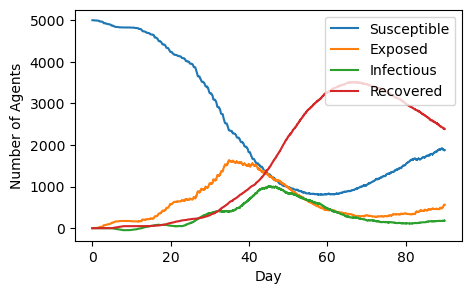

In [17]:
plt.figure(figsize=(5,3), dpi = 100)
x = np.arange(25920)
x_scaled = x / 288
plt.plot(x_scaled, count_S, label = 'Susceptible')
plt.plot(x_scaled, count_E, label = 'Exposed')
plt.plot(x_scaled, count_I, label = 'Infectious')
plt.plot(x_scaled, count_R, label = 'Recovered')
plt.xlabel('Day')
plt.ylabel('Number of Agents')
plt.legend(loc = 'upper right')
plt.savefig(log_dir + disease_version +'/figures/epi-curve.pdf', format = 'pdf',  bbox_inches='tight')
plt.close()